In [1]:
import torch
print(torch.cuda.is_available())


from detecto import core, utils, visualize
from detecto.visualize import show_labeled_image, plot_prediction_grid
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import numpy as np
import pandas as pd
import glob
import re
import os
import gc
import cv2

from Function_definitions import process_spectral_images, xywh_to_xyxy

pd.set_option('display.max_rows', 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 30)


True


In [2]:
gc.collect()

60

In [3]:
# # load data_final to pickle
pickle_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Tensors/'

data_NZ2023_a_final = pd.read_pickle(f'{pickle_path}data_NZ2023_a_final.pkl')
data_NZ2023_b_final = pd.read_pickle(f'{pickle_path}data_NZ2023_b_final.pkl')
data_NZ2023_c_final = pd.read_pickle(f'{pickle_path}data_NZ2023_c_final.pkl')
data_NZ2023_d_final = pd.read_pickle(f'{pickle_path}data_NZ2023_d_final.pkl')
data_NZ2024_a_final = pd.read_pickle(f'{pickle_path}data_NZ2024_a_final.pkl')
data_NZ2024_b_final = pd.read_pickle(f'{pickle_path}data_NZ2024_b_final.pkl')
data_NZ2024_c_final = pd.read_pickle(f'{pickle_path}data_NZ2024_c_final.pkl')
data_NZ2024_d_final = pd.read_pickle(f'{pickle_path}data_NZ2024_d_final.pkl')
data_UK2024_a_final = pd.read_pickle(f'{pickle_path}data_UK2024_a_final.pkl')
data_UK2024_b_final = pd.read_pickle(f'{pickle_path}data_UK2024_b_final.pkl')
data_UK2024_c_final = pd.read_pickle(f'{pickle_path}data_UK2024_c_final.pkl')
data_UK2024_d_final = pd.read_pickle(f'{pickle_path}data_UK2024_d_final.pkl')


# pickle_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Tensors/'

# Generate the missing images 
# Load missing data then run concatenate with counter after running for data_x_x_final
data_NZ2023_a_missing = pd.read_pickle(f'{pickle_path}data_NZ2023_a_missing.pkl')
data_NZ2023_b_missing = pd.read_pickle(f'{pickle_path}data_NZ2023_b_missing.pkl')
data_NZ2023_c_missing = pd.read_pickle(f'{pickle_path}data_NZ2023_c_missing.pkl')
data_NZ2023_d_missing = pd.read_pickle(f'{pickle_path}data_NZ2023_d_missing.pkl')
data_NZ2024_a_missing = pd.read_pickle(f'{pickle_path}data_NZ2024_a_missing.pkl')
data_NZ2024_b_missing = pd.read_pickle(f'{pickle_path}data_NZ2024_b_missing.pkl')
data_NZ2024_c_missing = pd.read_pickle(f'{pickle_path}data_NZ2024_c_missing.pkl')
data_NZ2024_d_missing = pd.read_pickle(f'{pickle_path}data_NZ2024_d_missing.pkl')
data_UK2024_a_missing = pd.read_pickle(f'{pickle_path}data_UK2024_a_missing.pkl')
data_UK2024_b_missing = pd.read_pickle(f'{pickle_path}data_UK2024_b_missing.pkl')
data_UK2024_c_missing = pd.read_pickle(f'{pickle_path}data_UK2024_c_missing.pkl')
data_UK2024_d_missing = pd.read_pickle(f'{pickle_path}data_UK2024_d_missing.pkl')




In [4]:
data_NZ2023_a_final = pd.concat([data_NZ2023_a_final, data_NZ2023_a_missing])
data_NZ2023_b_final = pd.concat([data_NZ2023_b_final, data_NZ2023_b_missing])
data_NZ2023_c_final = pd.concat([data_NZ2023_c_final, data_NZ2023_c_missing])
data_NZ2023_d_final = pd.concat([data_NZ2023_d_final, data_NZ2023_d_missing])
data_NZ2024_a_final = pd.concat([data_NZ2024_a_final, data_NZ2024_a_missing])
data_NZ2024_b_final = pd.concat([data_NZ2024_b_final, data_NZ2024_b_missing])
data_NZ2024_c_final = pd.concat([data_NZ2024_c_final, data_NZ2024_c_missing])
data_NZ2024_d_final = pd.concat([data_NZ2024_d_final, data_NZ2024_d_missing])
data_UK2024_a_final = pd.concat([data_UK2024_a_final, data_UK2024_a_missing])
data_UK2024_b_final = pd.concat([data_UK2024_b_final, data_UK2024_b_missing])
data_UK2024_c_final = pd.concat([data_UK2024_c_final, data_UK2024_c_missing])
data_UK2024_d_final = pd.concat([data_UK2024_d_final, data_UK2024_d_missing])

In [5]:
# print(data_NZ2023_a_final)
# print(data_NZ2023_b_final)
# print(data_NZ2023_c_final)
# print(data_NZ2023_d_final)
# print(data_NZ2024_a_final)
# print(data_NZ2024_b_final)
# print(data_NZ2024_c_final)
# print(data_NZ2024_d_final)
# print(data_UK2024_a_final)
# print(data_UK2024_b_final)
# print(data_UK2024_c_final)
# print(data_UK2024_d_final)

In [6]:
# print(data_NZ2023_a_final.head())
# print(data_NZ2024_b_final.head())
# print(data_UK2024_c_final.head())
# print(data_UK2024_d_final['Spectral_folder_D'][0])

In [7]:
# print(len(data_NZ2023_a_final))
# print(len(data_NZ2023_b_final))
# print(len(data_NZ2023_c_final))
# print(len(data_NZ2023_d_final))
# print(len(data_NZ2024_a_final))
# print(len(data_NZ2024_b_final))
# print(len(data_NZ2024_c_final))
# print(len(data_NZ2024_d_final))
# print(len(data_UK2024_a_final))
# print(len(data_UK2024_b_final))
# print(len(data_UK2024_c_final))
# print(len(data_UK2024_d_final))

In [8]:
# Spectral folder

# Split by '/' and remove last split in string



# data_NZ2023_a_final['Spectral_folder_a'] = data_NZ2023_a_final['Image_folder_A'].str.split('/').str[:-1].str.join('/')
# data_NZ2023_b_final['Spectral_folder_b'] = data_NZ2023_b_final['Image_folder_B'].str.split('/').str[:-1].str.join('/')
# data_NZ2023_c_final['Spectral_folder_c'] = data_NZ2023_c_final['Image_folder_C'].str.split('/').str[:-1].str.join('/')
# data_NZ2023_d_final['Spectral_folder_d'] = data_NZ2023_d_final['Image_folder_D'].str.split('/').str[:-1].str.join('/')
# data_NZ2024_a_final['Spectral_folder_a'] = data_NZ2024_a_final['Image_folder_A'].str.split('/').str[:-1].str.join('/')
# data_NZ2024_b_final['Spectral_folder_b'] = data_NZ2024_b_final['Image_folder_B'].str.split('/').str[:-1].str.join('/')
# data_NZ2024_c_final['Spectral_folder_c'] = data_NZ2024_c_final['Image_folder_C'].str.split('/').str[:-1].str.join('/')
# data_NZ2024_d_final['Spectral_folder_d'] = data_NZ2024_d_final['Image_folder_D'].str.split('/').str[:-1].str.join('/')
# data_UK2024_a_final['Spectral_folder_a'] = data_UK2024_a_final['Image_folder_A'].str.split('/').str[:-1].str.join('/')
# data_UK2024_b_final['Spectral_folder_b'] = data_UK2024_b_final['Image_folder_B'].str.split('/').str[:-1].str.join('/')
# data_UK2024_c_final['Spectral_folder_c'] = data_UK2024_c_final['Image_folder_C'].str.split('/').str[:-1].str.join('/')
# data_UK2024_d_final['Spectral_folder_d'] = data_UK2024_d_final['Image_folder_D'].str.split('/').str[:-1].str.join('/')

In [9]:
# print(data_NZ2023_a_final['Spectral_folder_a'][0])
# print(data_NZ2024_b_final['Spectral_folder_b'][0])
# print(data_UK2024_c_final['Spectral_folder_c'][0])

In [10]:
# test = data_UK2024_d_final[:4]
# print(test)
# print(test['Spectral_folder_D'][0])

In [11]:
# folder_path = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/'
# loc_link = 'spectral_UK_2024/'
# img_path = glob.glob(f'{folder_path}{loc_link}{test["Spectral_folder_D"][0]}/REFLECTANCE*.png')
# print(img_path[0])
# original_img = utils.read_image(img_path[0])
# plt.imshow(original_img)

In [12]:
# # Code to check that the function works correctly

# side = 'D'
# height=512
# width=512
# aggregate_pixel_height=30, 
# aggregate_pixel_width=30
# df = test
# folder_path = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/'
# loc_link = 'spectral_UK_2024/'

# processed_images = []
# file_metadata = []

# fig, axes = plt.subplots(len(df),2, figsize=(10, len(df)*5))
                         
# for index, row in df.iterrows():
#     print(f"Processing {index + 1}/{len(df)}")

#     spectral_link = row[f'Spectral_folder_{side}']
#     dat_file = glob.glob(f"{folder_path}{loc_link}{spectral_link}/*.dat")

#     if not dat_file:
#             print(f"No .dat file found in {spectral_link}. Skipping...")
#             continue

#     # Load Spectral Data
#     spec_data = np.fromfile(dat_file[0], dtype=np.float32)
#     bands = len(spec_data) // (height * width)
#     spec_data = spec_data.reshape(height, bands, width)
#     spec_data = np.transpose(spec_data, (2, 0, 1))  # Convert to (H, W, B)
#     spectral_flipped = np.fliplr(spec_data)

#     spectral_flipped_normalised = (spectral_flipped - np.min(spectral_flipped)) / (np.max(spectral_flipped) - np.min(spectral_flipped)) * 255
#     spectral_flipped_normalised = spectral_flipped_normalised.astype(np.uint8)


#     mask = row['tensors']['segmentation']
#     img_with_mask = spectral_flipped.copy()
#     img_with_mask[mask == 0] = 0

#     img_with_mask_normalised = (img_with_mask - np.min(img_with_mask)) / (np.max(img_with_mask) - np.min(img_with_mask)) * 255
#     img_with_mask_normalised = img_with_mask_normalised.astype(np.uint8)


#     x, y, w, h = row['tensors']['bbox']
#     x1 = int(x)
#     y1 = int(y)
#     x2 = int(x + w)
#     y2 = int(y + h)

#     bbox = np.array([x1, y1, x2, y2])

#     #Compare original with segmented
#     red_band2 = spectral_flipped_normalised[:, :, 69]
#     green_band2 = spectral_flipped_normalised[:, :, 52]
#     blue_band2 = spectral_flipped_normalised[:, :, 18]
#     rgb_image2 = np.stack([red_band2, green_band2, blue_band2], axis=-1)

#     # Segemented images
#     red_band = img_with_mask_normalised[:, :, 69]
#     green_band = img_with_mask_normalised[:, :, 52]
#     blue_band = img_with_mask_normalised[:, :, 18]
#     rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

#     image_segment = rgb_image[y1:y2, x1:x2]
#     image_segment2 = rgb_image2[y1:y2, x1:x2]

    
#     # axes[index].imshow(image_segment)
#     # axes[index].set_title(f"Image {index + 1}")

    
#     # Plot the segmented image
#     axes[index, 0].imshow(image_segment)
#     axes[index, 0].set_title(f"Segmented Image {index + 1}")

#     # Plot the non-segmented image
#     axes[index, 1].imshow(image_segment2)
#     axes[index, 1].set_title(f"Non-Segmented Image {index + 1}")



#     # plt.imshow(image_segment)
#     # plt.show()

#     # axes.imshow(rgb_image)
# # Segment the image


# plt.tight_layout()
# plt.show



In [13]:
# folder_path = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/'
# loc_link = 'spectral_UK_2024/'

# test_res, files = process_spectral_images(test, side='D', folder_path=folder_path, loc_link = 'spectral_UK_2024/', height=512, width=512, aggregate_pixel_height=30, aggregate_pixel_width=30)

In [14]:
# print(test_res[1])

In [15]:
img_size = 30
# img_size = 50

In [16]:
folder_path = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/'


# test_res = process_spectral_images(test, side='D', folder_path=folder_path, loc_link = 'spectral_UK_2024/', height=512, width=512, aggregate_pixel_height=30, aggregate_pixel_width=30)

if img_size == 30:
# Images at 30x30
    images_NZ2023_a, files_NZ2023_a = process_spectral_images(data_NZ2023_a_final, folder_path = folder_path, loc_link = 'spectral_NZ_2023/', side='A', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
    images_NZ2023_b, files_NZ2023_b = process_spectral_images(data_NZ2023_b_final, folder_path = folder_path, loc_link = 'spectral_NZ_2023/', side='B', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
    images_NZ2023_c, files_NZ2023_c = process_spectral_images(data_NZ2023_c_final, folder_path = folder_path, loc_link = 'spectral_NZ_2023/', side='C', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
    images_NZ2023_d, files_NZ2023_d = process_spectral_images(data_NZ2023_d_final, folder_path = folder_path, loc_link = 'spectral_NZ_2023/', side='D', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
elif img_size == 50:
    # Images at 50x50
    images_NZ2023_a, files_NZ2023_a = process_spectral_images(data_NZ2023_a_final, folder_path = folder_path, loc_link = 'spectral_NZ_2023/', side='A', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
    images_NZ2023_b, files_NZ2023_b = process_spectral_images(data_NZ2023_b_final, folder_path = folder_path, loc_link = 'spectral_NZ_2023/', side='B', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
    images_NZ2023_c, files_NZ2023_c = process_spectral_images(data_NZ2023_c_final, folder_path = folder_path, loc_link = 'spectral_NZ_2023/', side='C', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
    images_NZ2023_d, files_NZ2023_d = process_spectral_images(data_NZ2023_d_final, folder_path = folder_path, loc_link = 'spectral_NZ_2023/', side='D', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)






Processing 1/1668
Processing 2/1668
Processing 3/1668
Processing 4/1668
Processing 5/1668
Processing 6/1668
Processing 7/1668
Processing 8/1668
Processing 9/1668
Processing 10/1668
Processing 11/1668
Processing 12/1668
Processing 13/1668
Processing 14/1668
Processing 15/1668
Processing 16/1668
Processing 17/1668
Processing 18/1668
Processing 19/1668
Processing 20/1668
Processing 21/1668
Processing 22/1668
Processing 23/1668
Processing 24/1668
Processing 25/1668
Processing 26/1668
Processing 27/1668
Processing 28/1668
Processing 29/1668
Processing 30/1668
Processing 31/1668
Processing 32/1668
Processing 33/1668
Processing 34/1668
Processing 35/1668
Processing 36/1668
Processing 37/1668
Processing 38/1668
Processing 39/1668
Processing 40/1668
Processing 41/1668
Processing 42/1668
Processing 43/1668
Processing 44/1668
Processing 45/1668
Processing 46/1668
Processing 47/1668
Processing 48/1668
Processing 49/1668
Processing 50/1668
Processing 51/1668
Processing 52/1668
Processing 53/1668
Pr

In [17]:
print(data_NZ2023_a_final[:1])

                  Image_folder_A    image_filename_A      ID  Number  \
0  20230328 Fuji PFR orchard ...  2023-03-28_002.png  Fuji_1     1.0   

   Firmness1  Firmness2   Brix  Starch  Starch2    Streif  Avg_firmness  \
0       6.38       6.23  12.43    50.0      8.0  4.057924         6.305   

  Cultivar              Spectral_folder_A  Count  \
0     Fuji  20230328 Fuji PFR orchard ...      6   

                         tensors  
0  {'segmentation': [[False, ...  


In [18]:
counter = 1
# counter = 21756 # Continue from the last number in the previous file
def concatenate_with_counter(row):
    global counter
    result = f"{row['ID']}_{counter}"
    counter += 1
    return result

In [19]:
# files_NZ2023_a = pd.DataFrame(files_NZ2023_a)
# files_NZ2023_a.explode('sorted_tensor').reset_index(drop=True)

# files_NZ2023_b = pd.DataFrame(files_NZ2023_b)
# files_NZ2023_b.explode('sorted_tensor').reset_index(drop=True)

# files_NZ2023_c = pd.DataFrame(files_NZ2023_c)
# files_NZ2023_c.explode('sorted_tensor').reset_index(drop=True)

# files_NZ2023_d = pd.DataFrame(files_NZ2023_d)
# files_NZ2023_d.explode('sorted_tensor').reset_index(drop=True)




In [20]:
# files = pd.read_pickle(f'/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/aggregated_files_NZ2023_a.pkl')

# print(files.head(4))

In [21]:
# # print(files[:3])

# files_pd = pd.DataFrame(files)
# print(files_pd[:3])


In [22]:
# files_pd['img_ID'] =files_pd.apply(concatenate_with_counter, axis=1)
# files_pd.to_pickle(f'{pickle_path}files_test.pkl')


In [23]:
# print(files_pd)

In [24]:
# save the metadata and processed images 

files_NZ2023_a = pd.DataFrame(files_NZ2023_a)
files_NZ2023_a['img_ID'] = files_NZ2023_a.apply(concatenate_with_counter, axis=1)
files_NZ2023_a.to_pickle(f'{pickle_path}aggregated_files_NZ2023_a.pkl')

files_NZ2023_b = pd.DataFrame(files_NZ2023_b)
files_NZ2023_b['img_ID'] = files_NZ2023_b.apply(concatenate_with_counter, axis=1)
files_NZ2023_b.to_pickle(f'{pickle_path}aggregated_files_NZ2023_b.pkl')

files_NZ2023_c = pd.DataFrame(files_NZ2023_c)
files_NZ2023_c['img_ID'] = files_NZ2023_c.apply(concatenate_with_counter, axis=1)
files_NZ2023_c.to_pickle(f'{pickle_path}aggregated_files_NZ2023_c.pkl')

files_NZ2023_d = pd.DataFrame(files_NZ2023_d)
files_NZ2023_d['img_ID'] = files_NZ2023_d.apply(concatenate_with_counter, axis=1)
files_NZ2023_d.to_pickle(f'{pickle_path}aggregated_files_NZ2023_d.pkl')




In [25]:
if img_size ==30:
    #save 30x30 images
    spectral_folder_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/30x/'
elif img_size ==50:    
    # Save 50x50 images
    spectral_folder_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/'



In [26]:
# for i, arr in enumerate(test_res):
#         file_name = files_pd.iloc[i]['img_ID']

#         print(f"Saving {file_name}...")
#         np.save(f"{spectral_folder_path}NZ2023/30px_{file_name}.npy", arr)

In [27]:
if img_size == 30:
    #30x30px
    for i, arr in enumerate(images_NZ2023_a):
        file_name = files_NZ2023_a.iloc[i]['img_ID']

        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2023/30px_{file_name}.npy", arr)

    for i, arr in enumerate(images_NZ2023_b):
        file_name = files_NZ2023_b.iloc[i]['img_ID']

        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2023/30px_{file_name}.npy", arr)

    for i, arr in enumerate(images_NZ2023_c):
        file_name = files_NZ2023_c.iloc[i]['img_ID']

        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2023/30px_{file_name}.npy", arr)

    for i, arr in enumerate(images_NZ2023_d):
        file_name = files_NZ2023_d.iloc[i]['img_ID']

        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2023/30px_{file_name}.npy", arr)

elif img_size == 50:
    for i, arr in enumerate(images_NZ2023_a):
        file_name = files_NZ2023_a.iloc[i]['img_ID']
    
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2023/50px_{file_name}.npy", arr)

    for i, arr in enumerate(images_NZ2023_b):
        file_name = files_NZ2023_b.iloc[i]['img_ID']
        
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2023/50px_{file_name}.npy", arr)
    
    for i, arr in enumerate(images_NZ2023_c):
        file_name = files_NZ2023_c.iloc[i]['img_ID']
        
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2023/50px_{file_name}.npy", arr)
    
    for i, arr in enumerate(images_NZ2023_d):
        file_name = files_NZ2023_d.iloc[i]['img_ID']
        
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2023/50px_{file_name}.npy", arr)


Saving Fuji_1_1...
Saving Fuji_2_2...
Saving Fuji_3_3...
Saving Fuji_4_4...
Saving Fuji_5_5...
Saving Fuji_6_6...
Saving Fuji_7_7...
Saving Fuji_8_8...
Saving Fuji_9_9...
Saving Fuji_10_10...
Saving Fuji_11_11...
Saving Fuji_12_12...
Saving Fuji_25_13...
Saving Fuji_26_14...
Saving Fuji_27_15...
Saving Fuji_28_16...
Saving Fuji_29_17...
Saving Fuji_30_18...
Saving Fuji_31_19...
Saving Fuji_32_20...
Saving Fuji_33_21...
Saving Fuji_34_22...
Saving Fuji_35_23...
Saving Fuji_36_24...
Saving Fuji_37_25...
Saving Fuji_38_26...
Saving Fuji_39_27...
Saving Fuji_40_28...
Saving Fuji_41_29...
Saving Fuji_42_30...
Saving Fuji_49_31...
Saving Fuji_50_32...
Saving Fuji_51_33...
Saving Fuji_52_34...
Saving Fuji_53_35...
Saving Fuji_54_36...
Saving Fuji_55_37...
Saving Fuji_56_38...
Saving Fuji_57_39...
Saving Fuji_58_40...
Saving Fuji_59_41...
Saving Fuji_60_42...
Saving Fuji_61_43...
Saving Fuji_62_44...
Saving Fuji_63_45...
Saving Fuji_64_46...
Saving Fuji_65_47...
Saving Fuji_66_48...
Saving Fuj

In [28]:
# # repeat process for NZ2024 and UK2024

if img_size == 30:
    images_NZ2024_a, files_NZ2024_a = process_spectral_images(data_NZ2024_a_final, folder_path = folder_path, loc_link = 'spectral_NZ_2024/', side='A', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
    images_NZ2024_b, files_NZ2024_b = process_spectral_images(data_NZ2024_b_final, folder_path = folder_path, loc_link = 'spectral_NZ_2024/', side='B', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
    images_NZ2024_c, files_NZ2024_c = process_spectral_images(data_NZ2024_c_final, folder_path = folder_path, loc_link = 'spectral_NZ_2024/', side='C', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
    images_NZ2024_d, files_NZ2024_d = process_spectral_images(data_NZ2024_d_final, folder_path = folder_path, loc_link = 'spectral_NZ_2024/', side='D', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)

    images_UK2024_a, files_UK2024_a = process_spectral_images(data_UK2024_a_final, folder_path = folder_path, loc_link = 'spectral_UK_2024/', side='A', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
    images_UK2024_b, files_UK2024_b = process_spectral_images(data_UK2024_b_final, folder_path = folder_path, loc_link = 'spectral_UK_2024/', side='B', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
    images_UK2024_c, files_UK2024_c = process_spectral_images(data_UK2024_c_final, folder_path = folder_path, loc_link = 'spectral_UK_2024/', side='C', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)
    images_UK2024_d, files_UK2024_d = process_spectral_images(data_UK2024_d_final, folder_path = folder_path, loc_link = 'spectral_UK_2024/', side='D', aggregate_pixel_height = img_size, aggregate_pixel_width = img_size)


elif img_size == 50:
    # repeat process for NZ2024 and UK2024

    images_NZ2024_a, files_NZ2024_a = process_spectral_images(data_NZ2024_a_final, folder_path = folder_path, loc_link = 'spectral_NZ_2024/', side='A', aggregate_pixel_height = 50, aggregate_pixel_width = 50)
    images_NZ2024_b, files_NZ2024_b = process_spectral_images(data_NZ2024_b_final, folder_path = folder_path, loc_link = 'spectral_NZ_2024/', side='B', aggregate_pixel_height = 50, aggregate_pixel_width = 50)
    images_NZ2024_c, files_NZ2024_c = process_spectral_images(data_NZ2024_c_final, folder_path = folder_path, loc_link = 'spectral_NZ_2024/', side='C', aggregate_pixel_height = 50, aggregate_pixel_width = 50)
    images_NZ2024_d, files_NZ2024_d = process_spectral_images(data_NZ2024_d_final, folder_path = folder_path, loc_link = 'spectral_NZ_2024/', side='D', aggregate_pixel_height = 50, aggregate_pixel_width = 50)

    images_UK2024_a, files_UK2024_a = process_spectral_images(data_UK2024_a_final, folder_path = folder_path, loc_link = 'spectral_UK_2024/', side='A', aggregate_pixel_height = 50, aggregate_pixel_width = 50)
    images_UK2024_b, files_UK2024_b = process_spectral_images(data_UK2024_b_final, folder_path = folder_path, loc_link = 'spectral_UK_2024/', side='B', aggregate_pixel_height = 50, aggregate_pixel_width = 50)
    images_UK2024_c, files_UK2024_c = process_spectral_images(data_UK2024_c_final, folder_path = folder_path, loc_link = 'spectral_UK_2024/', side='C', aggregate_pixel_height = 50, aggregate_pixel_width = 50)
    images_UK2024_d, files_UK2024_d = process_spectral_images(data_UK2024_d_final, folder_path = folder_path, loc_link = 'spectral_UK_2024/', side='D', aggregate_pixel_height = 50, aggregate_pixel_width = 50)





Processing 1/1385
Processing 2/1385
Processing 3/1385
Processing 4/1385
Processing 5/1385
Processing 6/1385
Processing 7/1385
Processing 8/1385
Processing 9/1385
Processing 10/1385
Processing 11/1385
Processing 12/1385
Processing 13/1385
Processing 14/1385
Processing 15/1385
Processing 16/1385
Processing 17/1385
Processing 18/1385
Processing 19/1385
Processing 20/1385
Processing 21/1385
Processing 22/1385
Processing 23/1385
Processing 24/1385
Processing 25/1385
Processing 26/1385
Processing 27/1385
Processing 28/1385
Processing 29/1385
Processing 30/1385
Processing 31/1385
Processing 32/1385
Processing 33/1385
Processing 34/1385
Processing 35/1385
Processing 36/1385
Processing 37/1385
Processing 38/1385
Processing 39/1385
Processing 40/1385
Processing 41/1385
Processing 42/1385
Processing 43/1385
Processing 44/1385
Processing 45/1385
Processing 46/1385
Processing 47/1385
Processing 48/1385
Processing 49/1385
Processing 50/1385
Processing 51/1385
Processing 52/1385
Processing 53/1385
Pr

In [29]:

# files_NZ2024_a = pd.DataFrame(files_NZ2024_a)
# files_NZ2024_a.explode('sorted_tensor').reset_index(drop=True)
# files_NZ2024_b = pd.DataFrame(files_NZ2024_b)
# files_NZ2024_b.explode('sorted_tensor').reset_index(drop=True)
# files_NZ2024_c = pd.DataFrame(files_NZ2024_c)
# files_NZ2024_c.explode('sorted_tensor').reset_index(drop=True)
# files_NZ2024_d = pd.DataFrame(files_NZ2024_d)
# files_NZ2024_d.explode('sorted_tensor').reset_index(drop=True)

# files_UK2024_a = pd.DataFrame(files_UK2024_a)
# files_UK2024_a.explode('sorted_tensor').reset_index(drop=True)
# files_UK2024_b = pd.DataFrame(files_UK2024_b)
# files_UK2024_b.explode('sorted_tensor').reset_index(drop=True)
# files_UK2024_c = pd.DataFrame(files_UK2024_c)
# files_UK2024_c.explode('sorted_tensor').reset_index(drop=True)
# files_UK2024_d = pd.DataFrame(files_UK2024_d)
# files_UK2024_d.explode('sorted_tensor').reset_index(drop=True)

In [30]:
# save the metadata and processed images 
# Repeat for NZ2024 and UK2024

files_NZ2024_a = pd.DataFrame(files_NZ2024_a)
files_NZ2024_a['img_ID'] = files_NZ2024_a.apply(concatenate_with_counter, axis=1)
files_NZ2024_a.to_pickle(f'{pickle_path}aggregated_files_NZ2024_a.pkl')
files_NZ2024_b = pd.DataFrame(files_NZ2024_b)
files_NZ2024_b['img_ID'] = files_NZ2024_b.apply(concatenate_with_counter, axis=1)
files_NZ2024_b.to_pickle(f'{pickle_path}aggregated_files_NZ2024_b.pkl')
files_NZ2024_c = pd.DataFrame(files_NZ2024_c)
files_NZ2024_c['img_ID'] = files_NZ2024_c.apply(concatenate_with_counter, axis=1)
files_NZ2024_c.to_pickle(f'{pickle_path}aggregated_files_NZ2024_c.pkl')
files_NZ2024_d = pd.DataFrame(files_NZ2024_d)
files_NZ2024_d['img_ID'] = files_NZ2024_d.apply(concatenate_with_counter, axis=1)
files_NZ2024_d.to_pickle(f'{pickle_path}aggregated_files_NZ2024_d.pkl')

files_UK2024_a = pd.DataFrame(files_UK2024_a)
files_UK2024_a['img_ID'] = files_UK2024_a.apply(concatenate_with_counter, axis=1)
files_UK2024_a.to_pickle(f'{pickle_path}aggregated_files_UK2024_a.pkl')
files_UK2024_b = pd.DataFrame(files_UK2024_b)
files_UK2024_b['img_ID'] = files_UK2024_b.apply(concatenate_with_counter, axis=1)
files_UK2024_b.to_pickle(f'{pickle_path}aggregated_files_UK2024_b.pkl')
files_UK2024_c = pd.DataFrame(files_UK2024_c)
files_UK2024_c['img_ID'] = files_UK2024_c.apply(concatenate_with_counter, axis=1)
files_UK2024_c.to_pickle(f'{pickle_path}aggregated_files_UK2024_c.pkl')
files_UK2024_d = pd.DataFrame(files_UK2024_d)
files_UK2024_d['img_ID'] = files_UK2024_d.apply(concatenate_with_counter, axis=1)
files_UK2024_d.to_pickle(f'{pickle_path}aggregated_files_UK2024_d.pkl')


In [31]:
#30x30px
if img_size == 30:
    for i, arr in enumerate(images_NZ2024_a):
        file_name = files_NZ2024_a.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2024/30px_{file_name}.npy", arr)

    for i, arr in enumerate(images_NZ2024_b):
        file_name = files_NZ2024_b.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2024/30px_{file_name}.npy", arr)

    for i, arr in enumerate(images_NZ2024_c):
        file_name = files_NZ2024_c.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2024/30px_{file_name}.npy", arr)

    for i, arr in enumerate(images_NZ2024_d):
        file_name = files_NZ2024_d.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2024/30px_{file_name}.npy", arr)

elif img_size == 50:
    # for 50x50px images
    for i, arr in enumerate(images_NZ2024_a):
        file_name = files_NZ2024_a.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2024/50px_{file_name}.npy", arr)

    for i, arr in enumerate(images_NZ2024_b):
        file_name = files_NZ2024_b.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2024/50px_{file_name}.npy", arr)

    for i, arr in enumerate(images_NZ2024_c):
        file_name = files_NZ2024_c.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2024/50px_{file_name}.npy", arr)

    for i, arr in enumerate(images_NZ2024_d):
        file_name = files_NZ2024_d.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}NZ2024/50px_{file_name}.npy", arr)


Saving Gala_7_6545...
Saving Gala_8_6546...
Saving Gala_9_6547...
Saving Gala_10_6548...
Saving Gala_11_6549...
Saving Gala_12_6550...
Saving Gala_13_6551...
Saving Gala_14_6552...
Saving Gala_15_6553...
Saving Gala_16_6554...
Saving Gala_17_6555...
Saving Gala_18_6556...
Saving Gala_19_6557...
Saving Gala_20_6558...
Saving Gala_21_6559...
Saving Gala_22_6560...
Saving Gala_23_6561...
Saving Gala_24_6562...
Saving Gala_25_6563...
Saving Gala_26_6564...
Saving Gala_27_6565...
Saving Gala_28_6566...
Saving Gala_29_6567...
Saving Gala_30_6568...
Saving Gala_31_6569...
Saving Gala_32_6570...
Saving Gala_33_6571...
Saving Gala_34_6572...
Saving Gala_35_6573...
Saving Gala_36_6574...
Saving Gala_37_6575...
Saving Gala_38_6576...
Saving Gala_39_6577...
Saving Gala_40_6578...
Saving Gala_41_6579...
Saving Gala_42_6580...
Saving Gala_43_6581...
Saving Gala_44_6582...
Saving Gala_45_6583...
Saving Gala_46_6584...
Saving Gala_47_6585...
Saving Gala_48_6586...
Saving Gala_55_6587...
Saving Gala_56

In [32]:
if img_size == 30:
    #20x20 px
    for i, arr in enumerate(images_UK2024_a):
        file_name = files_UK2024_a.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}UK2024/30px_{file_name}.npy", arr)

    for i, arr in enumerate(images_UK2024_b):
        file_name = files_UK2024_b.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}UK2024/30px_{file_name}.npy", arr)

    for i, arr in enumerate(images_UK2024_c):
        file_name = files_UK2024_c.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}UK2024/30px_{file_name}.npy", arr)

    for i, arr in enumerate(images_UK2024_d):
        file_name = files_UK2024_d.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}UK2024/30px_{file_name}.npy", arr)

elif img_size == 50:
    # # Save 50x50 images
    for i, arr in enumerate(images_UK2024_a):
        file_name = files_UK2024_a.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}UK2024/50px_{file_name}.npy", arr)

    for i, arr in enumerate(images_UK2024_b):
        file_name = files_UK2024_b.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}UK2024/50px_{file_name}.npy", arr)

    for i, arr in enumerate(images_UK2024_c):
        file_name = files_UK2024_c.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}UK2024/50px_{file_name}.npy", arr)

    for i, arr in enumerate(images_UK2024_d):
        file_name = files_UK2024_d.iloc[i]['img_ID']
        print(f"Saving {file_name}...")
        np.save(f"{spectral_folder_path}UK2024/50px_{file_name}.npy", arr)


Saving Cox_1_12045...
Saving Cox_2_12046...
Saving Cox_3_12047...
Saving Cox_4_12048...
Saving Gala_5_12049...
Saving Gala_6_12050...
Saving Gala_7_12051...
Saving Gala_8_12052...
Saving Gala_9_12053...
Saving Gala_10_12054...
Saving Gala_11_12055...
Saving Gala_12_12056...
Saving Gala_13_12057...
Saving Gala_14_12058...
Saving Gala_15_12059...
Saving Gala_16_12060...
Saving Gala_17_12061...
Saving Gala_18_12062...
Saving Gala_19_12063...
Saving Gala_20_12064...
Saving Gala_21_12065...
Saving Gala_22_12066...
Saving Gala_23_12067...
Saving Gala_24_12068...
Saving Gala_25_12069...
Saving Gala_26_12070...
Saving Gala_27_12071...
Saving Gala_28_12072...
Saving Gala_29_12073...
Saving Gala_30_12074...
Saving Gala_31_12075...
Saving Gala_32_12076...
Saving Gala_33_12077...
Saving Gala_34_12078...
Saving Gala_35_12079...
Saving Gala_36_12080...
Saving Gala_37_12081...
Saving Gala_38_12082...
Saving Gala_39_12083...
Saving Gala_40_12084...
Saving Gala_41_12085...
Saving Gala_42_12086...
Savin

In [ ]:
# # files_UK2024_d.iloc[66]["sorted_tensor"][3]
# print(files_UK2024_d.iloc[66]['Spectral_folder_D'])

20230328 Fuji PFR orchard early pick/2023-03-28_053/results/


/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/20230328 Fuji PFR orchard early pick/2023-03-28_053/results/
['/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/20230328 Fuji PFR orchard early pick/2023-03-28_053/results/REFLECTANCE_2023-03-28_053.dat']
Max value: 1.0, Min value: 0.0


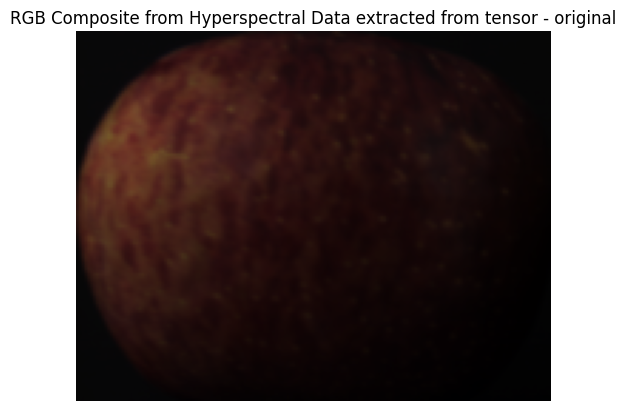

(30, 30, 204)
2.0733252


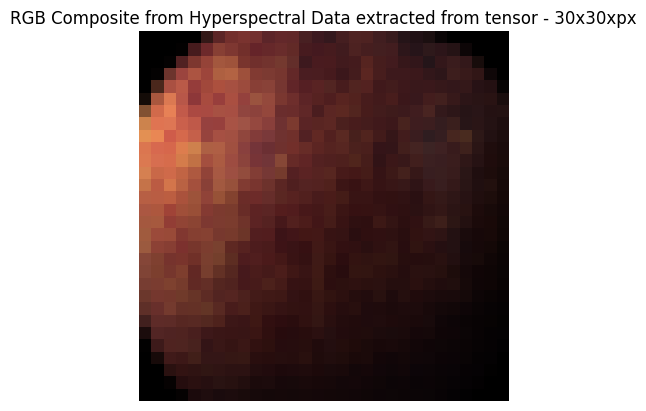

(50, 50, 204)
2.0789492


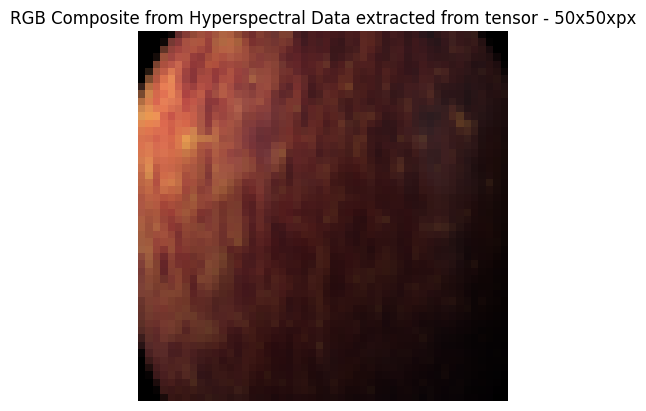

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import glob
# from Function_definitions import xywh_to_xyxy
# # Checking the saved images are correct

# files_NZ2023_d = pd.read_pickle(f'/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Tensors/aggregated_files_NZ2023_d1.pkl')

# file_name = files_NZ2023_d.iloc[66]['img_ID']

# # original

# Folder_path_UK2024 = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/'
# loc_link = 'spectral_NZ_2023/'
# side = 'D'
# spectral_link = Folder_path_UK2024 + loc_link + files_NZ2023_d.iloc[66]['Spectral_folder_D']
# print(spectral_link)
# dat_files = glob.glob(f"{spectral_link}/*.dat")
# print(dat_files)

# height_original = 512
# width_original = 512

# # Load spectral data

# spec_data = np.fromfile(dat_files[0], dtype=np.float32)
# bands = len(spec_data) // (height_original * width_original)
# spec_data = spec_data.reshape(height_original, bands, width_original)
# spec_data = np.transpose(spec_data, (2, 0, 1))  # Convert to (H, W, B)
# spectral_flipped = np.fliplr(spec_data)


# x, y, h, w = files_NZ2023_d.iloc[66]["tensors"]['bbox']
# x1, y1, x2, y2 = xywh_to_xyxy(files_NZ2023_d.iloc[66]["tensors"]['bbox'])
# x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
# image_segment = spectral_flipped[y1:y2, x1:x2]
# # image_segment = image_segment / 65535.0
# image_segment = (image_segment - image_segment.min()) / (image_segment.max() - image_segment.min())
# print(f'Max value: {np.max(image_segment)}, Min value: {np.min(image_segment)}')
# red_band = image_segment[:, :, 70]
# green_band = image_segment[:, :, 53]
# blue_band = image_segment[:, :, 19]
# rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
# # Display image
# plt.imshow(rgb_image)
# plt.axis("off")
# plt.title("RGB Composite from Hyperspectral Data extracted from tensor - original")
# plt.show()




# # 30x30px images
# spectral_folder_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/30x/'



# test_img = np.load(f"{spectral_folder_path}NZ2023/30px_{file_name}.npy")

# print(test_img.shape)

# print(test_img.max())


# red_band = test_img[:, :, 69]
# green_band = test_img[:, :, 52]
# blue_band = test_img[:, :, 18]
# rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
# # Display image
# plt.imshow(rgb_image)
# plt.axis("off")
# plt.title("RGB Composite from Hyperspectral Data extracted from tensor - 30x30xpx")
# plt.show()



# # 50x50 images
# spectral_folder_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/'

# test_img = np.load(f"{spectral_folder_path}NZ2023/50px_{file_name}.npy")


# print(test_img.shape)

# print(test_img.max())


# red_band = test_img[:, :, 69]
# green_band = test_img[:, :, 52]
# blue_band = test_img[:, :, 18]
# rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
# # Display image
# plt.imshow(rgb_image)
# plt.axis("off")
# plt.title("RGB Composite from Hyperspectral Data extracted from tensor - 50x50xpx")
# plt.show()





/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/20230328 Fuji PFR orchard early pick/2023-03-28_053/results/
['/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/20230328 Fuji PFR orchard early pick/2023-03-28_053/results/REFLECTANCE_2023-03-28_053.dat']
Max value: 1.0, Min value: 0.0


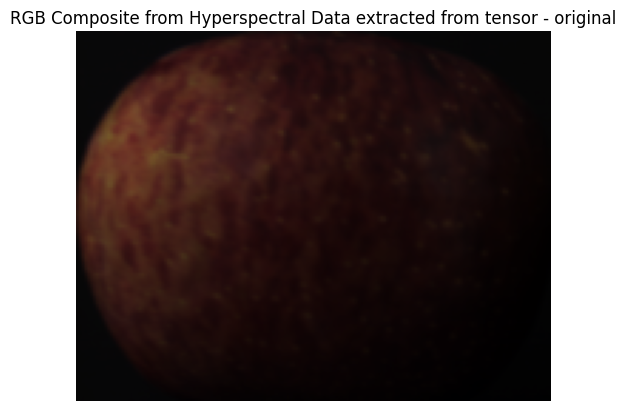

(30, 30, 204)
2.0733252


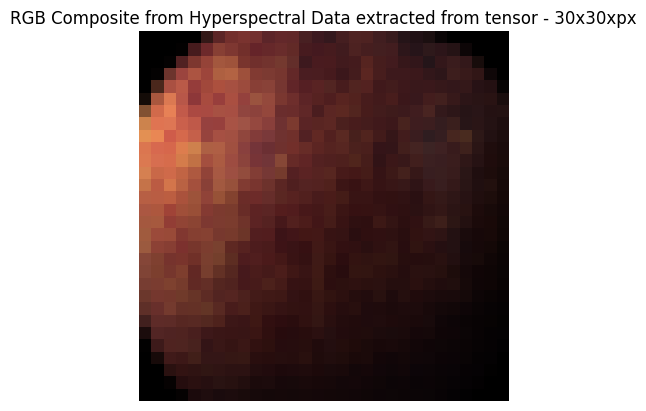

(50, 50, 204)
2.0789492


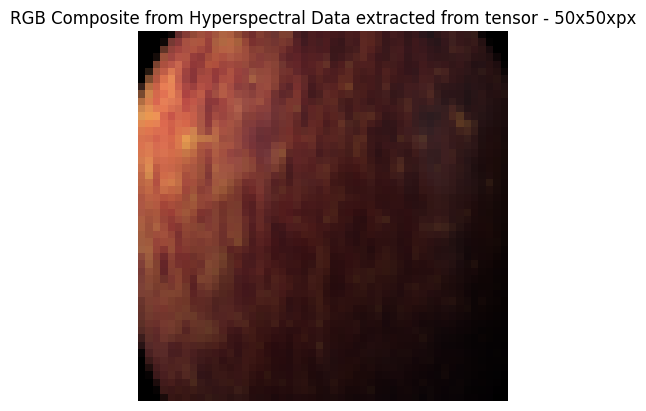

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import glob
# from Function_definitions import xywh_to_xyxy
# # Checking the saved images are correct

# files_NZ2023_d = pd.read_pickle(f'/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Tensors/aggregated_files_NZ2023_d1.pkl')

# file_name = files_NZ2023_d.iloc[66]['img_ID']

# # original

# Folder_path_UK2024 = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/'
# loc_link = 'spectral_NZ_2023/'
# side = 'D'
# spectral_link = Folder_path_UK2024 + loc_link + files_NZ2023_d.iloc[66]['Spectral_folder_D']
# print(spectral_link)
# dat_files = glob.glob(f"{spectral_link}/*.dat")
# print(dat_files)

# height_original = 512
# width_original = 512

# # Load spectral data

# spec_data = np.fromfile(dat_files[0], dtype=np.float32)
# bands = len(spec_data) // (height_original * width_original)
# spec_data = spec_data.reshape(height_original, bands, width_original)
# spec_data = np.transpose(spec_data, (2, 0, 1))  # Convert to (H, W, B)
# spectral_flipped = np.fliplr(spec_data)


# x, y, h, w = files_NZ2023_d.iloc[66]["tensors"]['bbox']
# x1, y1, x2, y2 = xywh_to_xyxy(files_NZ2023_d.iloc[66]["tensors"]['bbox'])
# x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
# image_segment = spectral_flipped[y1:y2, x1:x2]
# # image_segment = image_segment / 65535.0
# image_segment = (image_segment - image_segment.min()) / (image_segment.max() - image_segment.min())
# print(f'Max value: {np.max(image_segment)}, Min value: {np.min(image_segment)}')
# red_band = image_segment[:, :, 70]
# green_band = image_segment[:, :, 53]
# blue_band = image_segment[:, :, 19]
# rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
# # Display image
# plt.imshow(rgb_image)
# plt.axis("off")
# plt.title("RGB Composite from Hyperspectral Data extracted from tensor - original")
# plt.show()




# # 30x30px images
# spectral_folder_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/30x/'



# test_img = np.load(f"{spectral_folder_path}NZ2023/30px_{file_name}.npy")

# print(test_img.shape)

# print(test_img.max())


# red_band = test_img[:, :, 69]
# green_band = test_img[:, :, 52]
# blue_band = test_img[:, :, 18]
# rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
# # Display image
# plt.imshow(rgb_image)
# plt.axis("off")
# plt.title("RGB Composite from Hyperspectral Data extracted from tensor - 30x30xpx")
# plt.show()



# # 50x50 images
# spectral_folder_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/'

# test_img = np.load(f"{spectral_folder_path}NZ2023/50px_{file_name}.npy")


# print(test_img.shape)

# print(test_img.max())


# red_band = test_img[:, :, 69]
# green_band = test_img[:, :, 52]
# blue_band = test_img[:, :, 18]
# rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
# # Display image
# plt.imshow(rgb_image)
# plt.axis("off")
# plt.title("RGB Composite from Hyperspectral Data extracted from tensor - 50x50xpx")
# plt.show()



